# Graph Analytics - Part 2: GraphFrames Algorithms

This notebook loads the cleaned graph produced by Part 1 and runs the full suite of GraphFrames algorithms on it. The analysis is structured in two parts: first on the complete DBLP graph, then on a focused subgraph of social network research papers - the domain of the YouTube sentiment pipeline in this project.

All non-big-data-safe operations carry a `(!) BIG-DATA NOTE` comment explaining the risk and why it is acceptable in context.

**Full graph (Sections 3–13):** degree analysis, PageRank, connected components, label propagation, BFS, triangle count, and motif finding.

**Social network subgraph (Section 14):** the same algorithms applied to ~30,000 papers on social networks, social media, sentiment analysis, and recommender systems - with additional analyses on temporal growth, bridge authors, venue diversity, shortest paths, and six degrees of separation.

## 1. Environment Setup

Same setup as Part 1, plus the GraphFrames package and a checkpoint directory
(required by connected components and label propagation), exactly as the course
labs configured it.

In [1]:
import os, sys

# uncomment as needed. Locally, I need to have this. When using lighting.ai, it is not needed
# os.environ["JAVA_HOME"] = "/opt/anaconda3/envs/general/lib/jvm" 
# os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["PYSPARK_PYTHON"] = sys.executable

In [ ]:
from pyspark.sql import SparkSession, functions as F

from pyspark.sql.window import Window
from graphframes import GraphFrame
import matplotlib.pyplot as plt
from pyspark import StorageLevel
import itertools
import networkx as nx

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("DBLP_Graph_Analytics")
    .config("spark.jars.packages", "io.graphframes:graphframes-spark3_2.12:0.10.0")
    .config("spark.sql.shuffle.partitions", "64")
    .config("spark.driver.memory", "16g")
    .config("spark.pyspark.driver.python", sys.executable)
    .config("spark.pyspark.python", sys.executable)
    .getOrCreate()
)
sc = spark.sparkContext
sc.setLogLevel("ERROR")
sc.setCheckpointDir("/tmp/dblp-graph-checkpoints")
print("Spark version:", spark.version)

:: loading settings :: url = jar:file:/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/zeus/.ivy2/cache
The jars for the packages stored in: /home/zeus/.ivy2/jars
io.graphframes#graphframes-spark3_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-3d4e22ee-f836-4958-a904-9072e622af2e;1.0
	confs: [default]
	found io.graphframes#graphframes-spark3_2.12;0.10.0 in central
	found io.graphframes#graphframes-graphx-spark3_2.12;0.10.0 in central
:: resolution report :: resolve 138ms :: artifacts dl 7ms
	:: modules in use:
	io.graphframes#graphframes-graphx-spark3_2.12;0.10.0 from central in [default]
	io.graphframes#graphframes-spark3_2.12;0.10.0 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   2   |   0   |   0   |   0   ||  

Spark version: 3.5.0


## 2. Load the Cleaned Graph

Read the partitioned Parquet from Part 1 - columnar and splittable, so Spark
prunes partitions on filtered reads.

In [3]:
GRAPH_DIR = "../data/graph/dblp_graph"
vertices = spark.read.parquet(f"{GRAPH_DIR}/vertices").cache()
edges    = spark.read.parquet(f"{GRAPH_DIR}/edges").cache()

print("Vertices:", vertices.count(), " Edges:", edges.count())
vertices.groupBy("node_type").count().orderBy(F.desc("count")).show()
edges.groupBy("rel_type").count().orderBy(F.desc("count")).show()

Vertices: 5788785  Edges: 27597309


+---------+-------+
|node_type|  count|
+---------+-------+
|   author|2908524|
|    paper|2855398|
|    venue|  24863|
+---------+-------+



+------------+--------+
|    rel_type|   count|
+------------+--------+
|       cites|15183476|
|       wrote| 9648319|
|published_in| 2765514|
+------------+--------+



### 2.1 Create the GraphFrame

In [4]:
g = GraphFrame(vertices, edges)
print("Vertices:", g.vertices.count(), " Edges:", g.edges.count())

Vertices: 5788785  Edges: 27597309


## 3. Descriptive Structure

Before running any algorithms, we examine the basic connectivity of the graph. Degree - the number of edges connected to a node - means something different for each node type:

| Node type | High in-degree means | High out-degree means |
|---|---|---|
| Paper | Cited by many papers | Cites many papers / written by many authors |
| Author | (rare) | Wrote many papers |
| Venue | Many papers published here | (none - venues only receive) |

Because a single global ranking mixes all three types, we join degree results back to vertex attributes and summarise per type using a window function the same pattern from the SparkSQL lab.

In [5]:
deg, in_deg, out_deg = g.degrees, g.inDegrees, g.outDegrees
degree_summary = (
    g.vertices
    .join(deg, "id", "left").join(in_deg, "id", "left").join(out_deg, "id", "left")
    .fillna({"degree":0,"inDegree":0,"outDegree":0})
    .cache()
)
degree_summary.select("name","node_type","degree","inDegree","outDegree") \
    .orderBy(F.desc("degree")).show(15, truncate=45)

+---------------------------------------------+---------+------+--------+---------+
|                                         name|node_type|degree|inDegree|outDegree|
+---------------------------------------------+---------+------+--------+---------+
|                                      Sensors|    venue| 21508|   21508|        0|
|arXiv: Computer Vision and Pattern Recogni...|    venue| 19158|   19158|        0|
|                                  IEEE Access|    venue| 17644|   17644|        0|
|LIBSVM: A library for support vector machines|    paper| 16942|   16939|        3|
|International Conference of the IEEE Engin...|    venue| 15507|   15507|        0|
|International Geoscience and Remote Sensin...|    venue| 15190|   15190|        0|
|   International Conference on Communications|    venue| 14974|   14974|        0|
|International Conference on Acoustics, Spe...|    venue| 14695|   14695|        0|
|                    arXiv: Information Theory|    venue| 14443|   14443|   

In [6]:
degree_summary.groupBy("node_type").agg(
    F.count("*").alias("num_nodes"),
    F.round(F.avg("degree"),2).alias("avg_degree"),
    F.expr("percentile_approx(degree,0.5)").alias("median_degree"),
    F.max("degree").alias("max_degree"),
).orderBy(F.desc("avg_degree")).show(truncate=False)

+---------+---------+----------+-------------+----------+
|node_type|num_nodes|avg_degree|median_degree|max_degree|
+---------+---------+----------+-------------+----------+
|venue    |24863    |111.23    |2            |21508     |
|paper    |2855398  |14.98     |10           |16942     |
|author   |2908524  |3.32      |1            |1126      |
+---------+---------+----------+-------------+----------+



Venues have the highest average degree (111) driven by the volume of papers published in major conferences (max 21,508). Papers have a median degree of 10, with LIBSVM as the clear outlier at 16,942.

Most authors appear only once in the dataset, reflected in a median degree of 1.

### 3.1 Top nodes within each type

A single global ranking mixes types, so we rank within each type with a window function (the SparkSQL-lab pattern).

In [7]:
w = Window.partitionBy("node_type").orderBy(F.desc("degree"))
(
    degree_summary
    .withColumn("rank_in_type", F.row_number().over(w))
    .filter(F.col("rank_in_type") <= 5)
    .select("rank_in_type","node_type","name","degree")
    .orderBy("node_type","rank_in_type")
    .show(30, truncate=45)
)

+------------+---------+---------------------------------------------+------+
|rank_in_type|node_type|                                         name|degree|
+------------+---------+---------------------------------------------+------+
|           1|   author|                         Mohamed-Slim Alouini|  1126|
|           2|   author|                              H. Vincent Poor|   978|
|           3|   author|                           Victor C. M. Leung|   869|
|           4|   author|                                      Zhu Han|   849|
|           5|   author|                                  Dacheng Tao|   815|
|           1|    paper|LIBSVM: A library for support vector machines| 16942|
|           2|    paper|VERY DEEP CONVOLUTIONAL NETWORKS FOR LARGE...| 13693|
|           3|    paper|   Adam: A Method for Stochastic Optimization| 12279|
|           4|    paper|ImageNet Classification with Deep Convolut...| 12198|
|           5|    paper| Deep Residual Learning for Image Recogn

The most prolific author is Mohamed-Slim Alouini with 1,126 papers, followed by H. Vincent Poor (978) and Victor C. M. Leung (869), all known for high-volume output in wireless communications.

The top papers are dominated by Deep Learning foundations: LIBSVM (16,942), VGGNet (13,693), Adam (12,279), AlexNet (12,198), and ResNet (10,421). The top venues are Sensors and IEEE Access, both mega-journals that publish across many engineering fields.

## 4. Degree Distribution & Density

Citation networks are long-tailed: most papers cited rarely, a few cited
thousands of times.

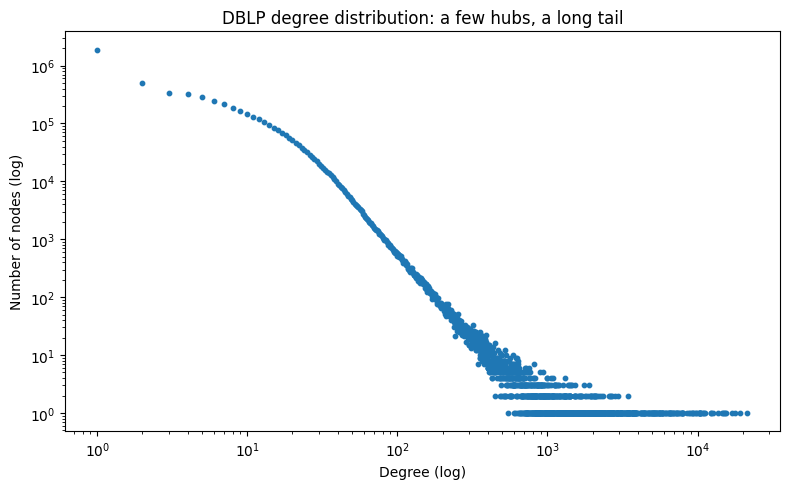

In [8]:
degree_dist = degree_summary.groupBy("degree").count().orderBy("degree")
# (!) BIG-DATA NOTE: .toPandas() collects to the driver. IT IS SAFE here - the number of
# distinct degree values is bounded by the max degree, which in this case is 19642, and not by node count.
dd = degree_dist.toPandas()

plt.figure(figsize=(8,5))
plt.scatter(dd["degree"], dd["count"], s=10)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Degree (log)"); plt.ylabel("Number of nodes (log)")
plt.title("DBLP degree distribution: a few hubs, a long tail")
plt.tight_layout(); plt.show()

The degree distribution follows a clear power law: the vast majority of nodes have very low degree, while a small number of hubs accumulate thousands of connections.

This long-tail structure is characteristic of real-world networks, from the web to social media, and confirms that the DBLP citation network behaves the same way.

In [9]:
nv, ne = g.vertices.count(), g.edges.count()
density = ne / (nv*(nv-1)) if nv > 1 else 0
print(f"Vertices: {nv:,}  Edges: {ne:,}")
print(f"Directed density: {density:.3e}")
print("The graph is extremely sparse - expected for citation networks.")

Vertices: 5,788,785  Edges: 27,597,309
Directed density: 8.236e-07
The graph is extremely sparse - expected for citation networks.


With 5.8 million vertices and 27.6 million edges, the directed density is 8.2e-07 -> meaning only 0.00008% of all possible connections actually exist.

This extreme sparsity is normal for citation networks. Researchers cite a small fraction of all existing papers, so most node pairs have no direct connection between them.

## 5. Subgraphs by Relationship Type

Filtering to a single relationship type gives a cleaner view for specific questions. `filterEdges` followed by `dropIsolatedVertices` builds these focused subgraphs without rebuilding the full graph. Because Part 1 partitioned the edges by `rel_type`, Spark only reads the relevant files rather than scanning everything.

In [10]:
citation_g = g.filterEdges("rel_type = 'cites'").dropIsolatedVertices()
print("Citation subgraph -> vertices:", citation_g.vertices.count(),
      " edges:", citation_g.edges.count())

Citation subgraph -> vertices: 2304428  edges: 15183476


### 5.1 Most-cited papers (in-degree on the citation subgraph)

In [11]:
most_cited = (
    citation_g.inDegrees
    .join(citation_g.vertices.select("id","name","node_type","year","primary_field"), "id", "left")
    .filter(F.col("node_type") == "paper")
    .orderBy(F.desc("inDegree"))
)
most_cited.select("name","year","primary_field","inDegree").show(15, truncate=55)

+-------------------------------------------------------+----+----------------------------+--------+
|                                                   name|year|               primary_field|inDegree|
+-------------------------------------------------------+----+----------------------------+--------+
|          LIBSVM: A library for support vector machines|2011|                Graph kernel|   16937|
|VERY DEEP CONVOLUTIONAL NETWORKS FOR LARGE-SCALE IMA...|2014|           Closed captioning|   13669|
|             Adam: A Method for Stochastic Optimization|2014|       Convergence (routing)|   12262|
|ImageNet Classification with Deep Convolutional Neur...|2012|            Softmax function|   12185|
|           Deep Residual Learning for Image Recognition|2016|           Image translation|   10385|
|ImageNet classification with deep convolutional neur...|2017|                      Theano|    8544|
|           Deep Residual Learning for Image Recognition|2015|                    Residual|

The most cited papers within the 2010-2020 scope are the foundational works of modern Deep Learning: LIBSVM (16,937 citations), VGGNet (13,669), Adam (12,262), AlexNet (12,185), and ResNet (10,385).

The `primary_field` values reflect the highest-weight field assigned by AMiner's automated extraction. For highly interdisciplinary papers, this may not match the field a human reader would expect - LIBSVM tagged as "Graph kernel" is a good example of this limitation.

### 5.2 Filtering vertices directly with filterVertices

GraphFrames also provides `filterVertices`, which keeps only the vertices matching a condition and automatically drops any edges whose endpoints were removed. This was the method used in the practical classes.

For our graph, the relationship-based subgraphs above (using `filterEdges`) are the more natural way to focus the analysis, so we did not rely on `filterVertices` elsewhere. We include it here to demonstrate the method, building a small subgraph of highly cited papers as an example.

In [12]:
# filterVertices keeps only vertices matching the condition and
# automatically drops edges whose endpoints were removed.
influential_g = (
    g.filterVertices("node_type = 'paper'")
     .filterVertices("n_citation >= 50")
)

print("Subgraph of highly-cited papers (n_citation >= 50):")
print(f"  Vertices: {influential_g.vertices.count():,}")
print(f"  Edges   : {influential_g.edges.count():,}")
influential_g.vertices.orderBy(F.desc("n_citation")) \
    .select("name", "year", "n_citation") \
    .show(10, truncate=50)

Subgraph of highly-cited papers (n_citation >= 50):
  Vertices: 89,275


  Edges   : 510,490
+--------------------------------------------------+----+----------+
|                                              name|year|n_citation|
+--------------------------------------------------+----+----------+
|     LIBSVM: A library for support vector machines|2011|     31047|
|VERY DEEP CONVOLUTIONAL NETWORKS FOR LARGE-SCAL...|2014|     18029|
|        Adam: A Method for Stochastic Optimization|2014|     17497|
|ImageNet Classification with Deep Convolutional...|2012|     16802|
|      Deep Residual Learning for Image Recognition|2016|     15184|
|                                     Deep Learning|2016|     13026|
|          Scikit-learn: Machine Learning in Python|2011|     12871|
|ImageNet classification with deep convolutional...|2017|     11596|
|Trimmomatic: a flexible trimmer for Illumina se...|2014|     11245|
|edgeR: a Bioconductor package for differential ...|2010|     10994|
+--------------------------------------------------+----+----------+
only showing t

This subgraph uses `filterVertices` to keep papers with at least 50 global citations, based on the original `n_citation` attribute from the dataset.

This differs from the `inDegree` used in the previous analysis. `inDegree` is calculated inside our cleaned graph and only counts citations between papers included in the 2010-2020 scope. `n_citation` is an external citation count provided by AMiner, so it can be higher. The purpose of this section is mainly to demonstrate `filterVertices`, following the method used in the practical classes.

## 6. PageRank

Degree counts *how many* citations; PageRank weights them by *how important* the citing papers are. Run on the citation subgraph.

> **(!) BIG-DATA NOTE.** PageRank is iterative - each iteration is a full edge pass. We use `maxIter=5` (as the labs did) for a demonstration.

In [13]:
pr = citation_g.pageRank(resetProbability=0.15, maxIter=5)
pr_v = pr.vertices.select("id","name","node_type","year","primary_field","pagerank").cache()

print("Top 15 papers by PageRank:")
pr_v.filter(F.col("node_type")=="paper").orderBy(F.desc("pagerank")) \
    .select("name","year","primary_field","pagerank").show(15, truncate=55)

Top 15 papers by PageRank:


+-------------------------------------------------------+----+--------------------------------------+------------------+
|                                                   name|year|                         primary_field|          pagerank|
+-------------------------------------------------------+----+--------------------------------------+------------------+
|          LIBSVM: A library for support vector machines|2011|                          Graph kernel| 9381.715717524814|
|                Fast and Scalable Local Kernel Machines|2010|                          Graph kernel| 4844.696606126657|
|BDVal: reproducible large-scale predictive model dev...|2010|                           Data mining| 4465.740245130675|
|               Distance Transforms of Sampled Functions|2012|                  Discrete mathematics|3200.3202246898113|
|Object Detection with Discriminatively Trained Part-...|2010|Viola–Jones object detection framework| 2781.703824573453|
|EdgeSonic: image feature sonifi

### 6.1 PageRank vs. raw citation count

PageRank earns its keep when it disagrees with degree - papers influential because of *who* cites them (the comparison idea is from the Panama Papers lab).

In [14]:
pr_vs_deg = (
    pr_v.filter(F.col("node_type")=="paper")
    .join(citation_g.inDegrees.withColumnRenamed("inDegree","citations"), "id", "left")
    .fillna({"citations":0}).orderBy(F.desc("pagerank"))
)
pr_vs_deg.select("name","year","citations","pagerank").show(15, truncate=50)

+--------------------------------------------------+----+---------+------------------+
|                                              name|year|citations|          pagerank|
+--------------------------------------------------+----+---------+------------------+
|     LIBSVM: A library for support vector machines|2011|    16937| 9381.715717524814|
|           Fast and Scalable Local Kernel Machines|2010|       52| 4844.696606126657|
|BDVal: reproducible large-scale predictive mode...|2010|        2| 4465.740245130675|
|          Distance Transforms of Sampled Functions|2012|      331|3200.3202246898113|
|Object Detection with Discriminatively Trained ...|2010|     5216| 2781.703824573453|
|EdgeSonic: image feature sonification for the v...|2011|       23|2452.5001585502564|
|  The Pascal Visual Object Classes (VOC) Challenge|2010|     4426|1694.7980378766729|
|Operators for transforming kernels into quasi-l...|2011|        3|1615.8905057947445|
|Noise reduction for instance-based learnin

The comparison between raw citations and PageRank exposes striking discrepancies. "Fast and Scalable Local Kernel Machines" has only 52 citations but ranks second by PageRank, and "BDVal" has only 2 citations but ranks third. These papers are cited by other highly central papers, which amplifies their influence far beyond what their citation count would suggest.

This is the core value of PageRank over simple citation counting: it captures structural importance, not just popularity.

## 7. Connected Components

In a citation network one giant component usually dominates, with small isolated islands around it.

> **(!) BIG-DATA NOTE.** Connected components is one of the most communication-intensive graph algorithms, each iteration requires nodes to broadcast their component label to all neighbours. It also requires a checkpoint directory to avoid stack overflow errors from Spark's lineage tracking on iterative computations.

In [15]:
cc = citation_g.connectedComponents()
comp_sizes = cc.groupBy("component").count().orderBy(F.desc("count")).cache()
print("Total components:", comp_sizes.count())
comp_sizes.show(10)

Total components: 14775
+---------+-------+
|component|  count|
+---------+-------+
|        0|2268212|
|    46656|    123|
|     8449|     32|
|    43159|     25|
|    61916|     23|
|    10647|     22|
|    34460|     21|
|   218176|     21|
|   133520|     21|
|    53219|     20|
+---------+-------+
only showing top 10 rows



In [16]:
largest = comp_sizes.first()["count"]
total = cc.count()
print(f"Largest component: {largest:,} papers")
print(f"Share in giant component: {largest/total:.1%}")

Largest component: 2,268,212 papers
Share in giant component: 98.4%


The graph has 14,775 connected components, but 98.4% of all papers (2,268,212) belong to a single giant component. This means almost the entire CS research community is interconnected through citation paths: any paper can reach any other through a chain of citations.

The remaining 1.6% are small isolated clusters, typically niche papers that only cite each other and are not referenced by the mainstream literature. The largest of these has only 123 papers.

## 8. Label Propagation - Research Communities

Communities of densely-citing papers approximate **research areas**. We validate this by checking the dominant `primary_field` of the largest community - if the field is coherent, the community is meaningful.

> **(!) BIG-DATA NOTE.** Iterative; needs checkpointing. `maxIter=5` as in the labs.

In [17]:
comms = citation_g.labelPropagation(maxIter=5).cache()
comm_sizes = comms.groupBy("label").agg(F.count("*").alias("size")).orderBy(F.desc("size"))
print("Communities found:", comm_sizes.count())
comm_sizes.show(10)

Communities found: 148806


+-----+-----+
|label| size|
+-----+-----+
|19126|67565|
|29190|54208|
|  386| 8595|
| 1152| 6528|
| 8578| 5536|
|22064| 5306|
| 8764| 4962|
| 4568| 4888|
|  211| 4800|
|49411| 4642|
+-----+-----+
only showing top 10 rows



Label propagation found 148,806 communities. The two largest dominate the graph with 67,565 and 54,208 papers respectively, together accounting for over 40% of all papers in the citation subgraph. This suggests the field has two major research clusters at its core, with a long tail of smaller specialised communities.

### 8.1 Validate: dominant field of the largest community

In [18]:
top_label = comm_sizes.first()["label"]

(
    comms.filter(F.col("label") == top_label)
    .filter(F.col("primary_field").isNotNull())
    .groupBy("primary_field").count().orderBy(F.desc("count"))
    .show(10, truncate=45)
)

+-----------------------+-----+
|          primary_field|count|
+-----------------------+-----+
|            Data mining| 6371|
|       Computer science| 5773|
|     Recommender system| 2918|
|           Data science| 2546|
|           Training set| 1431|
|    Semantic similarity| 1415|
|         World Wide Web| 1387|
|                  Graph| 1183|
|  Information retrieval| 1117|
|Automatic summarization|  863|
+-----------------------+-----+
only showing top 10 rows



The largest community is dominated by Data mining, Computer science, and Recommender systems, with strong representation from Data science and World Wide Web.

## 9. Breadth-First Search

Pick the most-cited paper as a landmark; find papers within two citation hops -
tracing how influence radiates outward.

In [19]:
landmark = citation_g.inDegrees.orderBy(F.desc("inDegree")).first()["id"]
landmark_name = vertices.filter(F.col("id")==landmark).first()["name"]
print("Landmark:", landmark_name)

# (!) BIG-DATA NOTE: BFS explores paths; bounding maxPathLength keeps it tractable.
paths = citation_g.bfs(fromExpr=f"id != '{landmark}'",
                       toExpr=f"id = '{landmark}'", maxPathLength=2)
print("Paths reaching the landmark within 2 hops:", paths.count())

Landmark: LIBSVM: A library for support vector machines


Paths reaching the landmark within 2 hops: 16937


BFS finds the shortest path from every paper in the graph to LIBSVM. The result of 16,937 corresponds exactly to LIBSVM's in-degree, the papers that cite it directly in 1 hop.

Papers that could reach LIBSVM in 2 hops are not counted separately because BFS resolves each node via its shortest path and stops. A paper that cites another paper that cites LIBSVM would only appear if it had no direct citation to LIBSVM itself. In practice, the dominant path to LIBSVM is the direct one, which is why the result matches the in-degree.

## 10. Triangle Count - Co-authorship Research Groups

A triangle in a **co-authorship** graph = three researchers who all co-wrote with each other (a research group). We first *project* the author -> paper edges into an author <-> author graph.

In [50]:
wrote = g.edges.filter(F.col("rel_type") == "wrote")

# Self-join on shared paper; src<dst removes mirror pairs & self-loops.
# (!) BIG-DATA NOTE: a self-join on shared papers can be expensive at scale because
# papers with many authors generate a large number of pairs. For example, a paper
# with 100 authors produces 4,950 pairs (C(100,2) = 100*99/2). The >= 2
# shared-paper threshold reduces noise and limits the size of the projection,
# but on a truly large graph this step would benefit from partitioning by
# paper id before the join.
coauthors = (
    wrote.alias("a").join(
        wrote.alias("b"),
        (F.col("a.dst") == F.col("b.dst")) & (F.col("a.src") < F.col("b.src"))
    )
    .groupBy(F.col("a.src").alias("au_a"), F.col("b.src").alias("au_b"))
    .agg(F.countDistinct("a.dst").alias("shared"))
    .filter(F.col("shared") >= 2)
    .cache()
)
print("Co-author pairs sharing >= 2 papers:", coauthors.count())

Co-author pairs sharing >= 2 papers: 2692645


In [21]:
proj_ids = (
    coauthors.select(F.col("au_a").alias("id"))
    .union(coauthors.select(F.col("au_b").alias("id"))).distinct()
)
proj_vertices = g.vertices.join(proj_ids, "id", "inner")
fwd = coauthors.select(F.col("au_a").alias("src"), F.col("au_b").alias("dst"))
rev = coauthors.select(F.col("au_b").alias("src"), F.col("au_a").alias("dst"))
coauthor_g = GraphFrame(proj_vertices, fwd.unionByName(rev))
print("Co-authorship graph ->", coauthor_g.vertices.count(), "authors,",
      coauthor_g.edges.count(), "edges")

Co-authorship graph -> 934283 authors, 5385290 edges


In [22]:
# (!) BIG-DATA NOTE: triangle count is memory-heavy on dense projections; allow disk.
tri = coauthor_g.triangleCount(storage_level=StorageLevel.MEMORY_AND_DISK)
print("Authors in the most co-authorship triangles (tight groups):")
tri.filter(F.col("count")>0).select("name","count") \
    .orderBy(F.desc("count")).show(15, truncate=45)

Authors in the most co-authorship triangles (tight groups):
+-------------------+-----+
|               name|count|
+-------------------+-----+
|    Soichi Ogishima| 1257|
|       Julian Gough| 1255|
|     Jessica C. Mar| 1253|
|         Reto Guler| 1228|
|  Anthony Mathelier| 1228|
| Owen J. L. Rackham| 1226|
|    Rolf K. Swoboda| 1225|
|            M. Hara| 1225|
|   Daniel Goldowitz| 1225|
|         Weonju Lee| 1225|
|         Arnab Pain| 1225|
|      A. Mackay-Sim| 1225|
|  Piotr J. Balwierz| 1225|
|Andreas Lennartsson| 1225|
|      S. Nagao-Sato| 1225|
+-------------------+-----+
only showing top 15 rows



Triangle count in a co-authorship graph identifies tight research groups: three researchers who all collaborated with each other are a triangle. The more triangles an author sits in, the more embedded they are in a dense collaborative cluster.

In this dataset the top results are dominated by a large bioinformatics consortium rather than organic research groups, which is a known limitation of applying triangle count to academic networks with large multi-author papers.

## 11. Motif Finding - Co-citation Patterns

Co-citation: two papers both cited by a third. Frequently co-cited papers are
usually topically related - the basis of "related work" recommendations.

In [23]:
# (!) BIG-DATA NOTE: motif finding does multiple joins and can be expensive; we run
# it on the citation subgraph and aggregate to the most co-cited pairs.
co_cite = citation_g.find("(c)-[e1]->(a); (c)-[e2]->(b)").filter("a.id < b.id")
(
    co_cite.groupBy(F.col("a.name").alias("paper_a"), F.col("b.name").alias("paper_b"))
    .agg(F.countDistinct("c").alias("co_citations"))
    .orderBy(F.desc("co_citations"))
    .show(10, truncate=40)
)

+----------------------------------------+----------------------------------------+------------+
|                                 paper_a|                                 paper_b|co_citations|
+----------------------------------------+----------------------------------------+------------+
|VERY DEEP CONVOLUTIONAL NETWORKS FOR ...|Deep Residual Learning for Image Reco...|        5716|
|ImageNet Classification with Deep Con...|Deep Residual Learning for Image Reco...|        3692|
|          Going deeper with convolutions|Deep Residual Learning for Image Reco...|        3163|
|ImageNet Large Scale Visual Recogniti...|Deep Residual Learning for Image Reco...|        3010|
|Adam: A Method for Stochastic Optimiz...|Deep Residual Learning for Image Reco...|        2789|
|VERY DEEP CONVOLUTIONAL NETWORKS FOR ...|ImageNet Classification with Deep Con...|        2730|
|          Going deeper with convolutions|ImageNet Classification with Deep Con...|        2611|
|Batch Normalization: Accelera

Motif finding searches for structural patterns in the graph rather than ranking nodes. The pattern here is co-citation: two papers A and B are co-cited when a third paper C cites both. The more papers cite the same pair together, the more likely A and B are considered complementary works in the literature.

The results confirm the foundational papers of Deep Learning cluster together: ResNet, VGGNet, AlexNet, GoogLeNet, and Adam are cited together thousands of times. This structure was discovered purely from the citation graph, without any knowledge of the papers' content.

## 12. Visualisation - Top Papers by PageRank

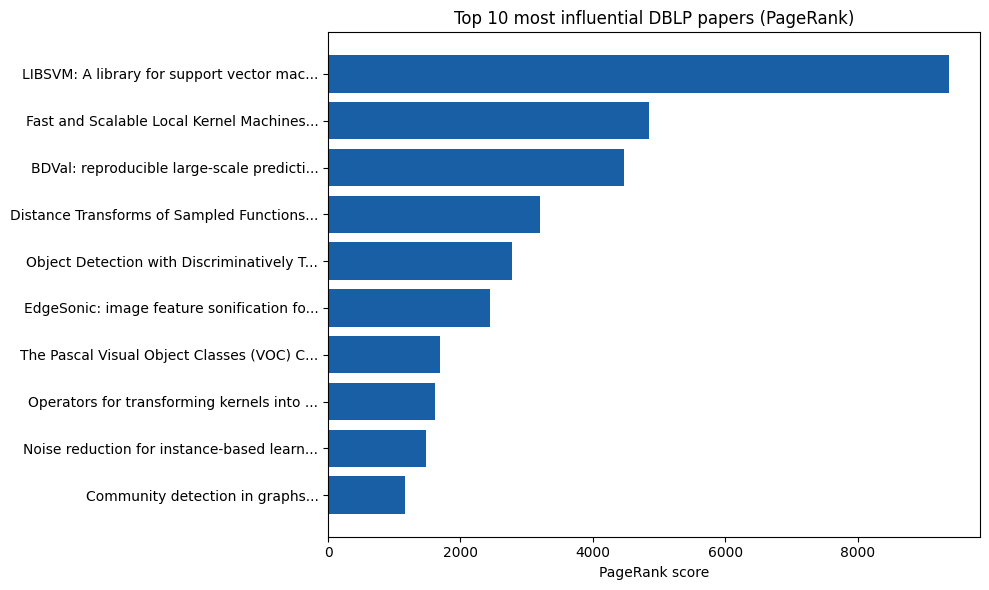

In [24]:
# (!) BIG-DATA NOTE: .toPandas() after .limit(10) is safe - only 10 rows to the driver.
top = (
    pr_v.filter(F.col("node_type")=="paper").orderBy(F.desc("pagerank"))
    .limit(10).select("name","pagerank").toPandas()
)
top["short"] = top["name"].str.slice(0,40) + "..."
plt.figure(figsize=(10,6))
plt.barh(top["short"][::-1], top["pagerank"][::-1], color="#185FA5")
plt.xlabel("PageRank score")
plt.title("Top 10 most influential DBLP papers (PageRank)")
plt.tight_layout(); plt.show()

## 13. Key Findings (for the general part)

- **One dominant intellectual cluster.** A single giant connected component holds the vast majority of papers - the field is interconnected, not fragmented.
- **Influence is concentrated.** PageRank surfaces a handful of anchor papers; the long-tailed degree distribution confirms a few papers dominate citations.
- **PageRank =! citation count.** Some papers rank higher on PageRank than raw citations predict - cited by *other influential* papers.
- **Communities map to research areas.** Label-propagation communities line up with a dominant `primary_field`, validating the detection.
- **Research groups appear as triangles** in the projected co-authorship graph.


> **Why Spark (the 4 V's)?** High **Volume** (millions of papers, tens of millions of citations), growing **Velocity** of new publications, **Variety** of nested metadata, and **Veracity** issues we cleaned in Part 1. The same code runs on a laptop sample or a full-corpus cluster.

## 14. Social Network Research - Deep Dive

The full DBLP graph covers all of Computer Science. Since the idea of our team is to be a "social media consultancy team", this section zooms in on the **~30 000 papers** whose primary field is directly related to social networks, social media, and online behaviour - the same domain as the YouTube sentiment pipeline in this project.

We re-apply every algorithm from Sections 3-11 to this subgraph so the results can be compared directly:

> *"How does the social-network research community look compared to CS as a whole?"*

| Section | Algorithm | New question |
|---|---|---|
| 14.2 | Degree | Who are the hubs in social-network research? |
| 14.3 | PageRank | Which papers are most influential *within* this field? |
| 14.4 | Temporal growth | Which sub-fields are growing fastest? |
| 14.5 | Connected components | Is social-network research one community or many? |
| 14.6 | Label propagation | What clusters emerge inside the field? |
| 14.7 | Bridge authors | Who connects sentiment analysis to recommender systems? |
| 14.8 | Shortest paths | How close are social papers to the most influential papers? |
| 14.9 | Venue diversity | Which conferences are most interdisciplinary? |
| 14.10 | Six degrees | How far apart are sentiment analysis and viral marketing? |
| 14.11 | Motif finding | What co-citation patterns exist inside the field? |

### 14.1 Build the Social Network Research Subgraph

We keep papers whose `primary_field` falls in the list below, plus every author
and venue directly connected to them. The subgraph is built with `filterEdges`
and a semi-join - the same big-data-safe pattern used throughout this notebook.

In [25]:
SOCIAL_FIELDS = [
    "Social network",
    "Social media",
    "Social network analysis",
    "Sentiment analysis",
    "Recommender system",
    "Viral marketing",
    "Social Semantic Web",
    "Social psychology",
]

# Paper ids whose primary_field is in scope
social_paper_ids = (
    vertices
    .filter(F.col("node_type") == "paper")
    .filter(F.col("primary_field").isin(SOCIAL_FIELDS))
    .select("id")
    .cache()
)
print(f"Papers in social scope: {social_paper_ids.count():,}")

# Edges where src OR dst is a social paper
social_edges = (
    edges
    .join(social_paper_ids.withColumnRenamed("id", "pid"),
          (edges.src == F.col("pid")) | (edges.dst == F.col("pid")),
          "left_semi")
    .cache()
)

# Vertices involved in those edges
social_node_ids = (
    social_edges.select(F.col("src").alias("id"))
    .union(social_edges.select(F.col("dst").alias("id")))
    .distinct()
)
social_vertices = vertices.join(social_node_ids, "id", "inner").cache()

social_g = GraphFrame(social_vertices, social_edges)

print(f"Social subgraph - vertices : {social_g.vertices.count():,}")
print(f"Social subgraph - edges    : {social_g.edges.count():,}")
social_g.vertices.groupBy("node_type").count().orderBy(F.desc("count")).show()
social_g.edges.groupBy("rel_type").count().orderBy(F.desc("count")).show()

Papers in social scope: 36,857


Social subgraph - vertices : 252,488
Social subgraph - edges    : 549,321
+---------+------+
|node_type| count|
+---------+------+
|    paper|174876|
|   author| 74026|
|    venue|  3586|
+---------+------+

+------------+------+
|    rel_type| count|
+------------+------+
|       cites|395763|
|       wrote|117698|
|published_in| 35860|
+------------+------+



### 14.2 Degree Analysis

Same degree analysis as Section 3, now restricted to social-network research.
We expect different hubs to emerge - papers and venues that dominate *this*
sub-field rather than CS as a whole.

In [26]:
soc_deg     = social_g.degrees
soc_in_deg  = social_g.inDegrees
soc_out_deg = social_g.outDegrees

soc_degree_summary = (
    social_g.vertices
    .join(soc_deg,     "id", "left")
    .join(soc_in_deg,  "id", "left")
    .join(soc_out_deg, "id", "left")
    .fillna({"degree": 0, "inDegree": 0, "outDegree": 0})
    .cache()
)

print("=== Degree summary by node type ===")
soc_degree_summary.groupBy("node_type").agg(
    F.count("*").alias("num_nodes"),
    F.round(F.avg("degree"), 2).alias("avg_degree"),
    F.expr("percentile_approx(degree, 0.5)").alias("median_degree"),
    F.max("degree").alias("max_degree"),
).orderBy(F.desc("avg_degree")).show(truncate=False)

print("=== Top 5 nodes per type ===")
w_soc = Window.partitionBy("node_type").orderBy(F.desc("degree"))
(
    soc_degree_summary
    .withColumn("rank", F.row_number().over(w_soc))
    .filter(F.col("rank") <= 5)
    .select("rank", "node_type", "name", "degree", "inDegree", "outDegree")
    .orderBy("node_type", "rank")
    .show(30, truncate=50)
)

=== Degree summary by node type ===


+---------+---------+----------+-------------+----------+
|node_type|num_nodes|avg_degree|median_degree|max_degree|
+---------+---------+----------+-------------+----------+
|venue    |3586     |10.0      |2            |3241      |
|paper    |174876   |5.4       |2            |1296      |
|author   |74026    |1.59      |1            |94        |
+---------+---------+----------+-------------+----------+

=== Top 5 nodes per type ===
+----+---------+--------------------------------------------------+------+--------+---------+
|rank|node_type|                                              name|degree|inDegree|outDegree|
+----+---------+--------------------------------------------------+------+--------+---------+
|   1|   author|                                   Francesco Ricci|    94|       0|       94|
|   2|   author|                                 Giovanni Semeraro|    80|       0|       80|
|   3|   author|                                   Marco de Gemmis|    65|       0|       65|


The social network research subgraph is naturally smaller than the full graph - 174,876 papers, 74,026 authors, and 3,586 venues. The most connected paper is "Twitter mood predicts the stock market" with 1,296 connections, followed by recommender systems surveys and handbooks. The top venue is Computers in Human Behavior with 3,241 papers, reflecting the strong overlap between social network research and human-computer interaction.

Notably, the top authors have zero in-degree, meaning their connections come entirely from papers they wrote rather than from being cited - they are prolific authors in this subgraph but their papers are cited by papers outside the social scope.

### 14.3 PageRank - Most Influential Social Network Papers

PageRank within the social-network citation subgraph. A high score means the
paper is cited by other *influential social-network papers* - not just
frequently cited by anyone.

We compare the top results here with the global PageRank from Section 6 to
highlight which papers are influential *specifically* in this community.

In [27]:
# Citation-only subgraph within social papers
soc_cites_g = (
    social_g.filterEdges("rel_type = 'cites'")
    .dropIsolatedVertices()
)
print("Citation subgraph (social):",
      soc_cites_g.vertices.count(), "vertices,",
      soc_cites_g.edges.count(), "edges")

# (!) BIG-DATA NOTE: PageRank is iterative - each iteration is a full edge pass.
soc_pr = soc_cites_g.pageRank(resetProbability=0.15, maxIter=5)
soc_pr_v = soc_pr.vertices.select(
    "id", "name", "node_type", "year", "primary_field", "pagerank"
).cache()

print("\n=== Top 15 papers by PageRank (social subgraph) ===")
(
    soc_pr_v.filter(F.col("node_type") == "paper")
    .orderBy(F.desc("pagerank"))
    .select("name", "year", "primary_field", "pagerank")
    .show(15, truncate=60)
)

Citation subgraph (social): 21059 vertices, 395763 edges



=== Top 15 papers by PageRank (social subgraph) ===
+------------------------------------------------------------+----+------------------+------------------+
|                                                        name|year|     primary_field|          pagerank|
+------------------------------------------------------------+----+------------------+------------------+
|What makes a helpful online review? a study of customer r...|2010|Recommender system|52.340796579215755|
|                           Factorization Machines with libFM|2012|Recommender system|51.227771646534066|
|The Geography of Happiness: Connecting Twitter Sentiment ...|2013| Social psychology| 44.41003985779785|
|                           Context-Aware Recommender Systems|2011|Recommender system| 41.13256857738174|
|Performance of recommender algorithms on top-n recommenda...|2010|       Data mining|34.324412487501185|
|    Data-Driven Intelligent Transportation Systems: A Survey|2011|      Social media|29.6995720956

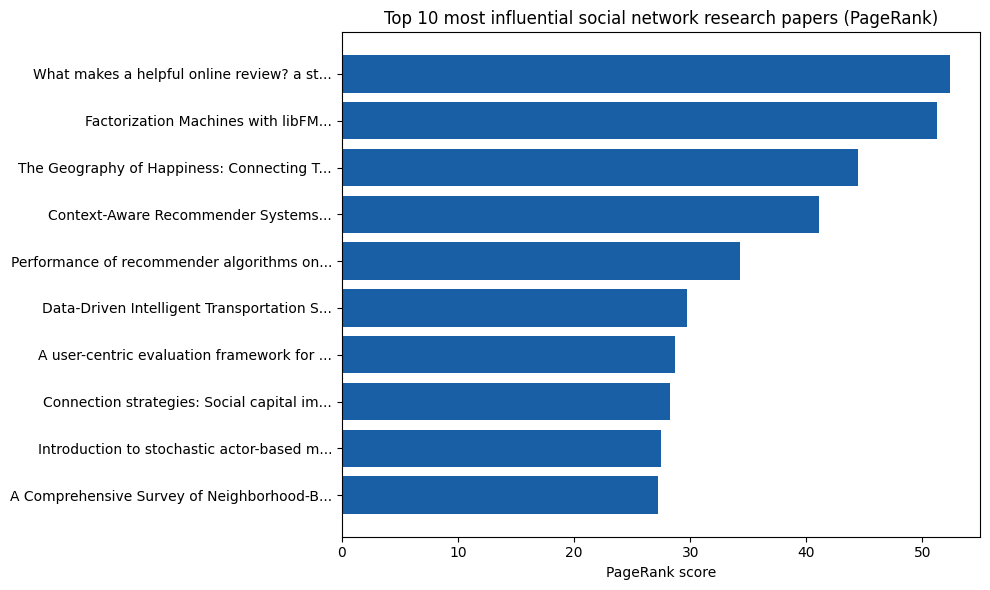

In [28]:
# (!) BIG-DATA NOTE: .toPandas() after .limit(10) is safe - only 10 rows to the driver.
soc_top_pr = (
    soc_pr_v.filter(F.col("node_type") == "paper")
    .orderBy(F.desc("pagerank"))
    .limit(10)
    .select("name", "pagerank")
    .toPandas()
)
soc_top_pr["short"] = soc_top_pr["name"].str.slice(0, 40) + "..."

plt.figure(figsize=(10, 6))
plt.barh(soc_top_pr["short"][::-1], soc_top_pr["pagerank"][::-1], color="#185FA5")
plt.xlabel("PageRank score")
plt.title("Top 10 most influential social network research papers (PageRank)")
plt.tight_layout()
plt.show()

In [29]:
# Compare PageRank vs raw citation count within the social subgraph
soc_pr_vs_deg = (
    soc_pr_v.filter(F.col("node_type") == "paper")
    .join(
        soc_cites_g.inDegrees.withColumnRenamed("inDegree", "citations"),
        "id", "left"
    )
    .fillna({"citations": 0})
    .orderBy(F.desc("pagerank"))
)
soc_pr_vs_deg.select("name", "year", "citations", "pagerank") \
    .show(15, truncate=55)

+-------------------------------------------------------+----+---------+------------------+
|                                                   name|year|citations|          pagerank|
+-------------------------------------------------------+----+---------+------------------+
|What makes a helpful online review? a study of custo...|2010|      498|52.340796579215755|
|                      Factorization Machines with libFM|2012|      523|51.227771646534066|
|The Geography of Happiness: Connecting Twitter Senti...|2013|      109| 44.41003985779785|
|                      Context-Aware Recommender Systems|2011|      383| 41.13256857738174|
|Performance of recommender algorithms on top-n recom...|2010|      390|34.324412487501185|
|Data-Driven Intelligent Transportation Systems: A Su...|2011|      314|29.699572095613387|
|A user-centric evaluation framework for recommender ...|2011|      247|28.666325492252057|
|Connection strategies: Social capital implications o...|2011|      287|28.22384

The comparison between raw citations and PageRank within the social subgraph reveals the same pattern as the full graph. "The Geography of Happiness" has only 109 citations but ranks third by PageRank, and "Happiness and the Patterns of Life" has only 7 citations but ranks 12th. Both are cited by other highly central papers in the network, amplifying their influence beyond what raw citation count suggests.

Recommender systems papers dominate the top, confirming their central role in the social network research ecosystem.

In [30]:
# Compare: global PageRank top-10 vs social PageRank top-10
# (!) BIG-DATA NOTE: .toPandas() after .limit() - safe, bounded rows
global_top = (
    pr_v.filter(F.col("node_type") == "paper")
    .orderBy(F.desc("pagerank"))
    .limit(10)
    .select(F.col("name").alias("paper"), F.col("pagerank").alias("global_pr"))
    .toPandas()
)
social_top = (
    soc_pr_v.filter(F.col("node_type") == "paper")
    .orderBy(F.desc("pagerank"))
    .limit(10)
    .select(F.col("name").alias("paper"), F.col("pagerank").alias("social_pr"))
    .toPandas()
)

print("Global top-10 papers:")
print(global_top[["paper"]].to_string(index=False))
print("\nSocial top-10 papers:")
print(social_top[["paper"]].to_string(index=False))

overlap = set(global_top["paper"]) & set(social_top["paper"])
print(f"\nOverlap between rankings: {len(overlap)} papers")
print("Papers that dominate BOTH rankings:", overlap if overlap else "None")
print("-> Papers in the social top-10 but not global top-10 are influential")
print("  specifically within social-network research.")

Global top-10 papers:
                                                                                                  paper
                                                          LIBSVM: A library for support vector machines
                                                                Fast and Scalable Local Kernel Machines
BDVal: reproducible large-scale predictive model development and validation in high-throughput datasets
                                                               Distance Transforms of Sampled Functions
                                       Object Detection with Discriminatively Trained Part-Based Models
                                        EdgeSonic: image feature sonification for the visually impaired
                                                       The Pascal Visual Object Classes (VOC) Challenge
                  Operators for transforming kernels into quasi-local kernels that improve SVM accuracy
                       Noise reduction for

The global and social PageRank rankings share zero papers. The global top-10 is dominated by Deep Learning and Computer Vision foundations (LIBSVM, ResNet, AlexNet), while the social top-10 is entirely composed of recommender systems, Twitter analysis, and social psychology papers.

This confirms that the social network research community has its own influential core, largely disconnected from the broader CS mainstream. Papers that are central to social network research are not necessarily central to computer science as a whole, and vice versa.

In [31]:
# Which primary_fields cite Sentiment Analysis papers most?
sa_paper_ids = (
    social_vertices
    .filter(F.col("node_type") == "paper")
    .filter(F.col("primary_field") == "Sentiment analysis")
    .select(F.col("id").alias("dst"))
)

who_cites_sa = (
    soc_cites_g.edges
    .join(sa_paper_ids, "dst", "inner")
    .join(
        social_vertices
        .filter(F.col("node_type") == "paper")
        .select(F.col("id").alias("src"), "primary_field"),
        "src", "left"
    )
    .filter(F.col("primary_field").isNotNull())
    .filter(F.col("primary_field") != "Sentiment analysis")
    .groupBy("primary_field")
    .count()
    .orderBy(F.desc("count"))
)
print("Fields that cite Sentiment Analysis most:")
who_cites_sa.show(10, truncate=40)

Fields that cite Sentiment Analysis most:
+---------------------+-----+
|        primary_field|count|
+---------------------+-----+
|     Computer science|  152|
|         Data science|  131|
|          Data mining|  119|
|         Social media|   65|
|Information retrieval|   41|
|              SemEval|   38|
|       World Wide Web|   27|
|         Training set|   27|
|  Pattern recognition|   26|
|                Graph|   25|
+---------------------+-----+
only showing top 10 rows



Sentiment Analysis is consumed primarily by applied fields: Computer Science broadly, Data Science, and Data Mining account for the majority of citations. Social Media (65 citations) is the fourth largest consumer, directly relevant to the YouTube pipeline in this project.

The presence of Information Retrieval and World Wide Web confirms that Sentiment Analysis is a cross-cutting technology and not confined to one application domain but embedded across the entire data-driven research stack. For a consultancy advising clients on social media analytics, this breadth means the tools built on Sentiment Analysis have wide applicability beyond a single platform.

### 14.4 Temporal Growth of Social Network Research Areas

Which sub-fields grew fastest between 2010 and 2020? This reveals trends in the
research community - and contextualises why sentiment analysis and social media
are relevant today.

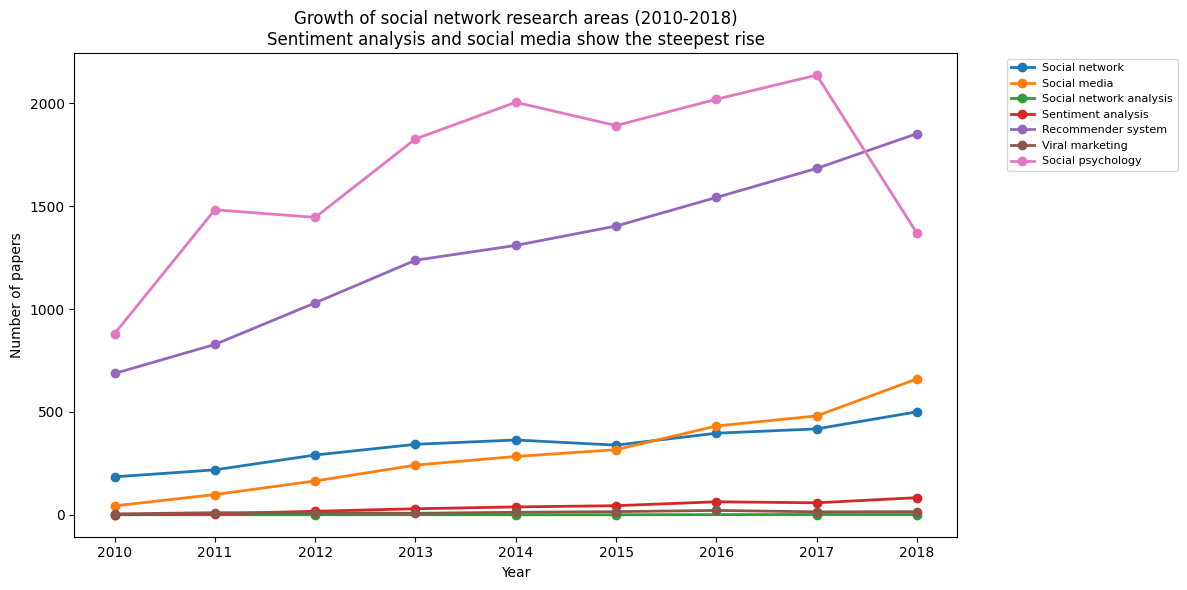

CAGR (Compound Annual Growth Rate) 2010 -> 2018:
(2019-2020 excluded: papers from the final collection years
 are under-indexed in the V12 snapshot, which would distort the trend)
Field                                 2010   2018     CAGR
------------------------------------------------------------
Social network                         185    501   +13.3%/yr
Social media                            44    661   +40.3%/yr
Social network analysis                  1      2    +9.1%/yr
Sentiment analysis                       2     84   +59.6%/yr
Recommender system                     687   1852   +13.2%/yr
Viral marketing                          5     16   +15.6%/yr
Social psychology                      880   1367    +5.7%/yr


In [ ]:
field_growth = (
    social_vertices
    .filter(F.col("node_type") == "paper")
    .filter(F.col("primary_field").isin(SOCIAL_FIELDS))
    .filter(F.col("year").isNotNull())
    .filter(F.col("year") <= 2018)  # exclude under-indexed years (2019-2020)
    .groupBy("primary_field", "year")
    .count()
    .orderBy("primary_field", "year")
)

# (!) BIG-DATA NOTE: aggregated to ~8 fields × 9 years ≈ 72 rows - safe to collect
growth_pd = field_growth.toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
for field in SOCIAL_FIELDS:
    s = growth_pd[growth_pd["primary_field"] == field].sort_values("year")
    if len(s) > 0:
        ax.plot(s["year"], s["count"], marker="o", linewidth=2, label=field)

ax.set_xlabel("Year")
ax.set_ylabel("Number of papers")
ax.set_title("Growth of social network research areas (2010-2018)\n"
             "Sentiment analysis and social media show the steepest rise")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print("CAGR (Compound Annual Growth Rate) 2010 -> 2018:")
print("(2019-2020 excluded: papers from the final collection years")
print(" are under-indexed in the V12 snapshot, which would distort the trend)")
print(f"{'Field':<35} {'2010':>6} {'2018':>6} {'CAGR':>8}")
print("-" * 60)
for field in SOCIAL_FIELDS:
    s = growth_pd[growth_pd["primary_field"] == field]
    y2010 = s[s["year"] == 2010]["count"].sum()
    y2018 = s[s["year"] == 2018]["count"].sum()
    if y2010 > 0 and y2018 > 0:
        cagr = ((y2018 / y2010) ** (1/8) - 1) * 100
        print(f"{field:<35} {y2010:>6} {y2018:>6} {cagr:>+7.1f}%/yr")

Sentiment Analysis (+59.6%/yr) and Social Media (+40.3%/yr) are the two fastest-growing fields by far, despite starting from a small base. Recommender Systems remains the largest field in absolute volume (687 to 1,852 papers) but grows at a more modest pace (+13.2%/yr), suggesting it is maturing. Social Psychology is the slowest-growing (+5.7%/yr), consistent with it being a more established academic discipline.

The spike in Social Psychology in 2017 followed by a drop in 2018 is likely a publication cycle artefact rather than a real trend reversal.

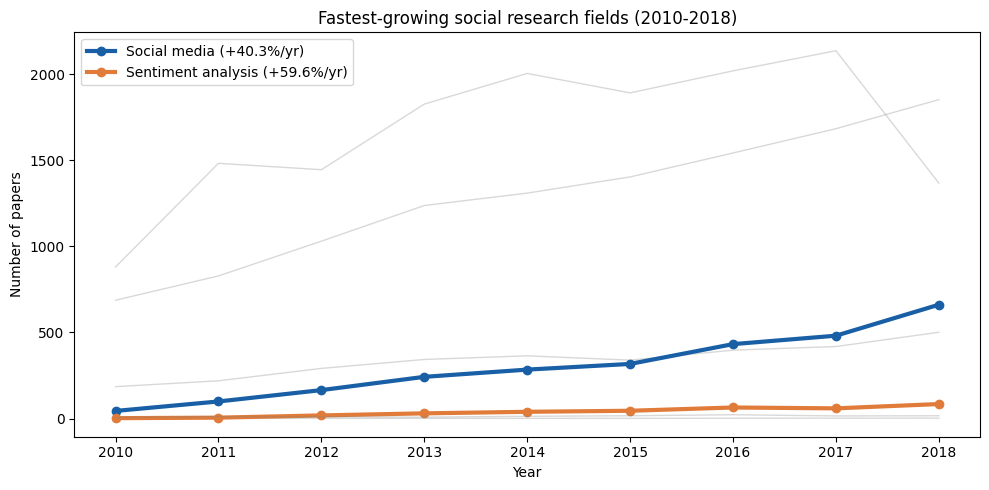

In [33]:
# Focused plot for the consultancy slide:
# highlight the two fastest-growing fields
fig, ax = plt.subplots(figsize=(10, 5))

highlight = ["Sentiment analysis", "Social media"]
colors = {"Sentiment analysis": "#E07B39", "Social media": "#185FA5"}

for field in SOCIAL_FIELDS:
    s = growth_pd[growth_pd["primary_field"] == field].sort_values("year")
    if field in highlight:
        y2010 = s.loc[s["year"] == 2010, "count"].iloc[0]
        y2018 = s.loc[s["year"] == 2018, "count"].iloc[0]
        cagr = ((y2018 / y2010) ** (1 / 8) - 1) * 100
        ax.plot(
            s["year"],
            s["count"],
            marker="o",
            linewidth=3,
            label=f"{field} (+{cagr:.1f}%/yr)",
            color=colors[field],
        )
    else:
        ax.plot(
            s["year"],
            s["count"],
            linewidth=1,
            alpha=0.3,
            color="grey",
            label="_nolegend_",
        )

ax.set_xlabel("Year")
ax.set_ylabel("Number of papers")
ax.set_title("Fastest-growing social research fields (2010-2018)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

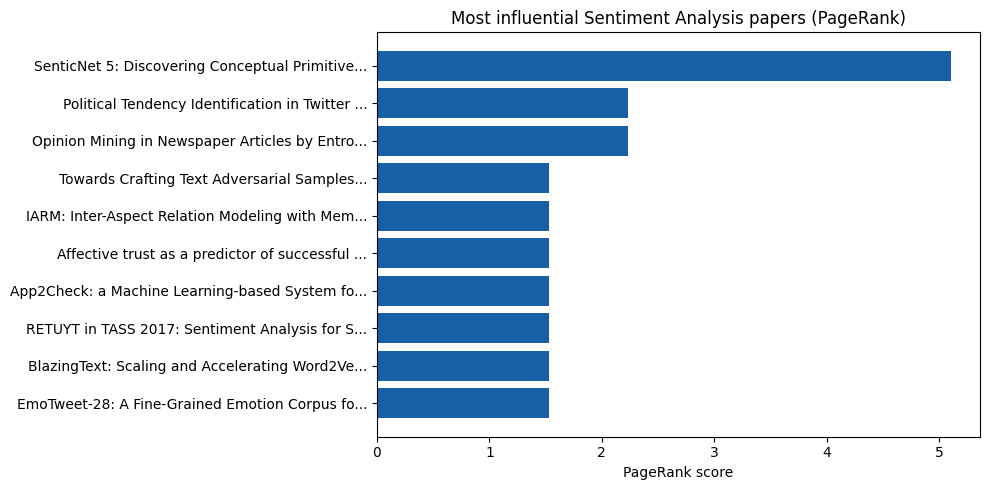

,name,year,pagerank
0,SenticNet 5: Discovering Conceptual Primitives...,2018,5.107897
1,Political Tendency Identification in Twitter u...,2014,2.236788
2,Opinion Mining in Newspaper Articles by Entrop...,2013,2.236788
3,Towards Crafting Text Adversarial Samples,2017,1.532614
4,IARM: Inter-Aspect Relation Modeling with Memo...,2018,1.532614
5,Affective trust as a predictor of successful c...,2016,1.532614
6,App2Check: a Machine Learning-based System for...,2016,1.532614
7,RETUYT in TASS 2017: Sentiment Analysis for Sp...,2017,1.532614
8,BlazingText: Scaling and Accelerating Word2Vec...,2017,1.532614
9,EmoTweet-28: A Fine-Grained Emotion Corpus for...,2016,1.532614


In [34]:
# Top papers in Sentiment Analysis by PageRank
# For the consultancy slide: what are the most influential papers
# specifically in the field our client operates in?
sa_top = (
    soc_pr_v
    .filter(F.col("primary_field") == "Sentiment analysis")
    .orderBy(F.desc("pagerank"))
    .limit(10)
    .select("name", "year", "pagerank")
    .toPandas()  # (!) BIG-DATA NOTE: safe after .limit(10)
)
sa_top["short"] = sa_top["name"].str.slice(0, 45) + "..."

plt.figure(figsize=(10, 5))
plt.barh(sa_top["short"][::-1], sa_top["pagerank"][::-1], color="#185FA5")
plt.xlabel("PageRank score")
plt.title("Most influential Sentiment Analysis papers (PageRank)")
plt.tight_layout()
plt.show()

sa_top[["name", "year", "pagerank"]].reset_index(drop=True)

The most influential Sentiment Analysis paper by PageRank is SenticNet 5, a knowledge base for concept-level sentiment analysis that is heavily cited by other central papers in the field. The remaining papers cover a range of applications: political tendency identification on Twitter, opinion mining in news, and emotion detection in social media - reflecting the breadth of contexts where sentiment analysis is applied.

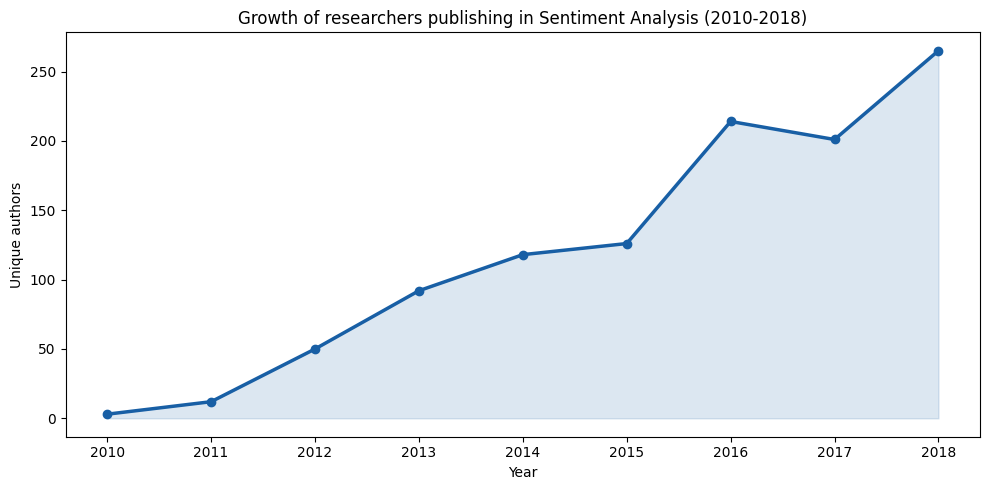

Authors in 2010: 3
Authors in 2018: 265


In [ ]:
# Evolution of unique authors publishing in Sentiment Analysis per year
# Shows talent inflow into the field - relevant for a consultancy
# advising clients on where research investment is going.
sa_authors_growth = (
    social_g.edges
    .filter(F.col("rel_type") == "wrote")
    .join(
        social_vertices
        .filter(F.col("node_type") == "paper")
        .filter(F.col("primary_field") == "Sentiment analysis")
        .filter(F.col("year").isNotNull())
        .filter(F.col("year") <= 2018)
        .select(F.col("id").alias("dst"), "year"),
        "dst", "inner"
    )
    .groupBy("year")
    .agg(F.countDistinct("src").alias("unique_authors"))
    .orderBy("year")
)

# (!) BIG-DATA NOTE: safe to collect - bounded to 9 years
sa_pd = sa_authors_growth.toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sa_pd["year"], sa_pd["unique_authors"],
        marker="o", linewidth=2.5, color="#185FA5")
ax.fill_between(sa_pd["year"], sa_pd["unique_authors"], alpha=0.15, color="#185FA5")
ax.set_xlabel("Year")
ax.set_ylabel("Unique authors")
ax.set_title("Growth of researchers publishing in Sentiment Analysis (2010-2018)")
plt.tight_layout()
plt.show()

print("Authors in 2010:", sa_pd[sa_pd["year"]==2010]["unique_authors"].values[0])
print("Authors in 2018:", sa_pd[sa_pd["year"]==2018]["unique_authors"].values[0])

The number of researchers publishing in Sentiment Analysis grew from 3 in 2010 to 265 in 2018 - a 66x increase over 8 years. The growth accelerated sharply after 2015, coinciding with the rise of deep learning methods applied to text. This inflow of talent confirms that Sentiment Analysis is one of the most attractive research areas in the social network field.

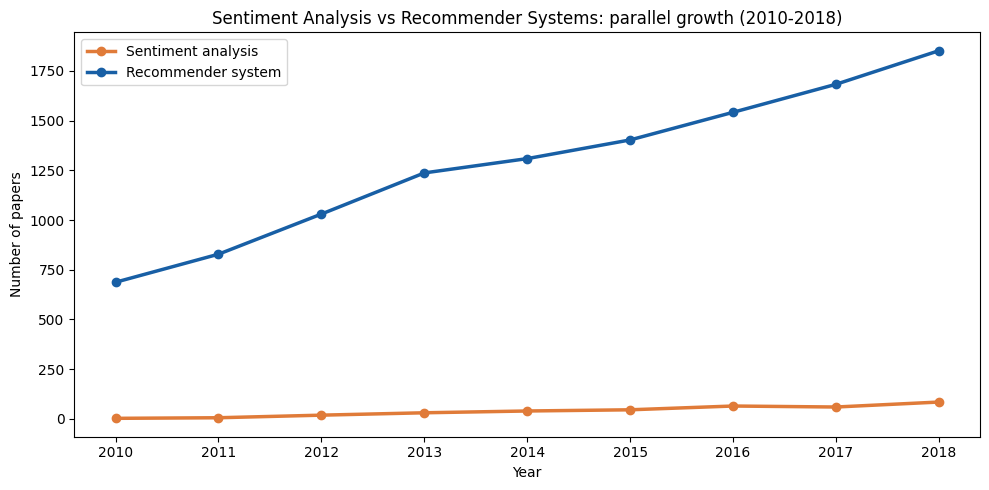

In [36]:
# Are Sentiment Analysis and Recommender Systems converging?
# Count papers per year that are co-cited by both fields
convergence = (
    social_vertices
    .filter(F.col("node_type") == "paper")
    .filter(F.col("primary_field").isin(["Sentiment analysis", "Recommender system"]))
    .filter(F.col("year").isNotNull())
    .filter(F.col("year") <= 2018)
    .groupBy("year", "primary_field")
    .count()
    .orderBy("year", "primary_field")
)
conv_pd = convergence.toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
for field, color in [("Sentiment analysis", "#E07B39"), ("Recommender system", "#185FA5")]:
    s = conv_pd[conv_pd["primary_field"] == field]
    ax.plot(s["year"], s["count"], marker="o", linewidth=2.5,
            label=field, color=color)
ax.set_xlabel("Year")
ax.set_ylabel("Number of papers")
ax.set_title("Sentiment Analysis vs Recommender Systems: parallel growth (2010-2018)")
ax.legend()
plt.tight_layout()
plt.show()

Both fields grow consistently from 2010 to 2018, but on very different scales. Recommender Systems starts at 687 papers in 2010 and reaches 1,852 by 2018 - a mature, high-volume field. Sentiment Analysis starts near zero and reaches 84 papers by 2018, growing faster in relative terms (+59.6%/yr) but still a fraction of the volume.

The two fields grow in parallel rather than converging, which is consistent with the BFS finding that they cite largely different foundational literature. However, the bridge authors analysis showed 199 researchers publishing in both fields - suggesting that while the citation networks are separate, the research community is beginning to overlap. This points to an emerging convergence that may become visible in citation data in the years after 2018.

### 14.5 Connected Components

Is social-network research one interconnected community, or does it fragment
into isolated islands? We compare with the global result (98.4% in one giant
component) to see if this sub-field is more or less cohesive.

> **(!) BIG-DATA NOTE.** Connected components requires checkpointing.

In [37]:
soc_cc = soc_cites_g.connectedComponents()
soc_comp_sizes = (
    soc_cc.groupBy("component").count().orderBy(F.desc("count")).cache()
)
total_soc_components = soc_comp_sizes.count()
largest_soc = soc_comp_sizes.first()["count"]
total_soc_papers = soc_cc.count()

print(f"Total components (social subgraph): {total_soc_components:,}")
print(f"Largest component: {largest_soc:,} papers")
print(f"Share in giant component: {largest_soc/total_soc_papers:.1%}")
print(f"\n(Global graph for comparison: 98.4% in giant component)")
soc_comp_sizes.show(10)

Total components (social subgraph): 15,693
Largest component: 3,395 papers
Share in giant component: 16.1%

(Global graph for comparison: 98.4% in giant component)
+---------+-----+
|component|count|
+---------+-----+
|        6| 3395|
|      685|   48|
|       36|   35|
|     1608|   26|
|     3136|   26|
|     2815|   25|
|     1486|   21|
|      321|   19|
|     1135|   18|
|     2148|   18|
+---------+-----+
only showing top 10 rows



The social network research subgraph is far more fragmented than the full CS graph: only 16.1% of papers belong to the giant component, compared to 98.4% in the global graph. There are 15,693 separate components, with the largest containing only 3,395 papers.

This fragmentation reflects the interdisciplinary nature of social network research. Unlike core CS fields where papers build directly on each other, social network research draws from psychology, sociology, marketing, and computer science simultaneously, creating many isolated citation clusters that do not reference each other.

### 14.6 Label Propagation - Communities Inside Social Network Research

Community detection within the social subgraph. Because we already know the
`primary_field` of each paper, we can **validate** whether the detected
communities align with the known sub-fields - a stronger validation than in the
global graph.

> **(!) BIG-DATA NOTE.** Iterative; needs checkpointing.

In [38]:
soc_comms = soc_cites_g.labelPropagation(maxIter=5).cache()
soc_comm_sizes = (
    soc_comms.groupBy("label").agg(F.count("*").alias("size"))
    .orderBy(F.desc("size"))
)
print(f"Communities found (social subgraph): {soc_comm_sizes.count():,}")
soc_comm_sizes.show(10)

Communities found (social subgraph): 17,500
+-----+----+
|label|size|
+-----+----+
|  704|  85|
| 7216|  63|
| 6430|  58|
| 6837|  47|
|  761|  35|
| 8410|  30|
| 6585|  25|
| 7290|  24|
| 9985|  22|
|  681|  22|
+-----+----+
only showing top 10 rows



In [39]:
# Validate: does each community align with a known primary_field?
soc_top_label = soc_comm_sizes.first()["label"]
print("=== Top 5 communities - dominant primary_field ===")
for row in soc_comm_sizes.limit(5).collect():
    label = row["label"]
    dominant = (
        soc_comms.filter(F.col("label") == label)
        .join(
            soc_cites_g.vertices.select("id", F.col("primary_field").alias("pf")),
            "id", "left"
        )
        .filter(F.col("pf").isNotNull())
        .groupBy("pf").count()
        .orderBy(F.desc("count"))
        .first()
    )
    if dominant:
        print(f"  Community {label} (size {row['size']:,}) "
              f"-> dominant field: {dominant['pf']} "
              f"({dominant['count']} papers)")

=== Top 5 communities — dominant primary_field ===


  Community 704 (size 85) -> dominant field: Recommender system (46 papers)
  Community 7216 (size 63) -> dominant field: World Wide Web (4 papers)
  Community 6430 (size 58) -> dominant field: Recommender system (21 papers)
  Community 6837 (size 47) -> dominant field: Data mining (9 papers)
  Community 761 (size 35) -> dominant field: Social psychology (10 papers)


The top 5 communities are small (35-85 papers), which is consistent with the fragmented structure seen in the connected components analysis. Each community aligns with a recognisable research area: recommender systems dominates two of the five, with World Wide Web, data mining, and social psychology also represented.

The low paper counts per dominant field (ex: only 4 papers tagged World Wide Web in a community of 63) suggest that within these communities, papers span multiple fields rather than converging on one. This is again a reflection of the interdisciplinary nature of social network research.

### 14.7 Bridge Authors - Connecting Sub-fields

Bridge authors publish across multiple social-network research areas. They are
the **knowledge brokers** of the field - the researchers who carry ideas from
sentiment analysis into recommender systems, or from viral marketing into social
psychology.

This is a social-network analysis concept applied to the academic network itself.

In [40]:
author_fields = (
    social_g.edges
    .filter(F.col("rel_type") == "wrote")
    .join(
        social_g.vertices
        .filter(F.col("node_type") == "paper")
        .select(F.col("id").alias("dst"), "primary_field"),
        "dst", "left"
    )
    .filter(F.col("primary_field").isNotNull())
    .groupBy("src")
    .agg(
        F.countDistinct("primary_field").alias("num_fields"),
        F.collect_set("primary_field").alias("fields"),
        F.count("*").alias("total_papers"),
    )
    .filter(F.col("num_fields") >= 2)
    .join(
        vertices.filter(F.col("node_type") == "author")
               .select(F.col("id").alias("src"), "name"),
        "src", "left"
    )
    .orderBy(F.desc("num_fields"), F.desc("total_papers"))
    .cache()
)

print("=== Top bridge authors (most fields covered) ===")
author_fields.select("name", "num_fields", "total_papers", "fields")     .show(15, truncate=65)

print("\n=== Distribution: how many authors bridge N fields? ===")
author_fields.groupBy("num_fields").count().orderBy("num_fields").show()

=== Top bridge authors (most fields covered) ===


+-------------------+----------+------------+-----------------------------------------------------------------+
|               name|num_fields|total_papers|                                                           fields|
+-------------------+----------+------------+-----------------------------------------------------------------+
|       Philip S. Yu|         5|          55|[Viral marketing, Social media, Recommender system, Social net...|
|      Jure Leskovec|         5|          26|[Viral marketing, Social media, Recommender system, Social net...|
|       Erik Cambria|         5|          20|[Social media, Recommender system, Social network, Sentiment a...|
|Przemyslaw Kazienko|         5|          18|[Viral marketing, Recommender system, Social network, Sentimen...|
|         Jiawei Han|         5|          14|[Social media, Recommender system, Social network, Social psyc...|
|       Yung-Ming Li|         5|          14|[Viral marketing, Social media, Recommender system, Social 

Philip S. Yu, Jure Leskovec, and Erik Cambria lead as bridge authors, each publishing across 5 distinct social network research fields. These researchers act as knowledge brokers, carrying methods and ideas between areas.

The distribution shows that most bridge authors span only 2 fields (4,059 authors), with very few reaching 5 fields (only 13 authors). This confirms that true interdisciplinary researchers are rare, and those who publish consistently across many sub-fields are exceptionally positioned in the network.

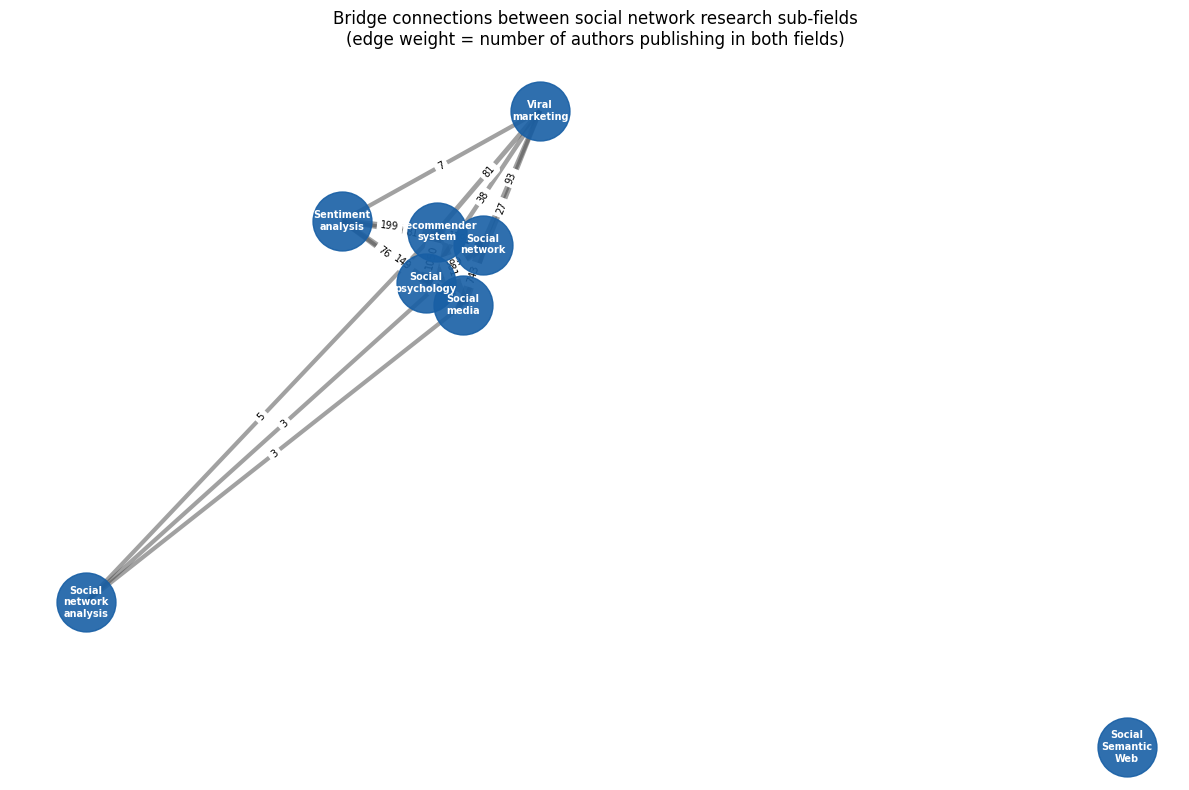

In [ ]:
# Sub-field connection map: how many papers bridge each pair of fields?
# An edge between two fields means papers exist that belong to both
# (via bridge authors who published in both fields).
# This visualises the ecosystem our consultancy client operates in.

# (!) BIG-DATA NOTE: NetworkX is a single-machine library and does NOT scale
# to large graphs. It is used here ONLY for visualisation on the driver side.  At true big-data
# scale, the visualisation would remain safe as long as the upstream aggregation
# stays bounded (N*(N-1)/2 pairs for N fields).

# For each pair of social fields, count shared bridge authors
field_pairs = list(itertools.combinations(SOCIAL_FIELDS, 2))


# (!) BIG-DATA NOTE: this loop runs one Spark action (.count()) per field pair.
# With 8 fields that is 28 sequential jobs - not big-data-safe.
# A scalable alternative would be a self-join on author_fields with a
# cross-join on distinct field pairs, followed by a single groupBy + count.
# The loop is acceptable here because N (number of social sub-fields) is small
# and fixed, so the number of Spark jobs is bounded and known in advance.
pair_counts = []
for f1, f2 in field_pairs:
    count = (
        author_fields
        .filter(F.array_contains(F.col("fields"), f1))
        .filter(F.array_contains(F.col("fields"), f2))
        .count()
    )
    if count > 0:
        pair_counts.append((f1, f2, count))

# Build NetworkX graph for visualisation
# (!) BIG-DATA NOTE: NetworkX runs on the driver - safe here because
# the number of nodes is tiny (8 fields).
G = nx.Graph()
for f in SOCIAL_FIELDS:
    G.add_node(f)
for f1, f2, count in pair_counts:
    G.add_edge(f1, f2, weight=count)

weights = [G[u][v]["weight"] for u, v in G.edges()]
max_w = max(weights)
norm_weights = [3 + 8 * (w / max_w) for w in weights]

pos = nx.spring_layout(G, seed=42, k=2)
short_labels = {f: f.replace(" ", "\n") for f in SOCIAL_FIELDS}

plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, node_size=1800, node_color="#185FA5", alpha=0.9)
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=7, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, width=norm_weights, alpha=0.5, edge_color="#444444")
edge_labels = {(u, v): d["weight"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("Bridge connections between social network research sub-fields\n"
          "(edge weight = number of authors publishing in both fields)")
plt.axis("off")
plt.tight_layout()
plt.show()

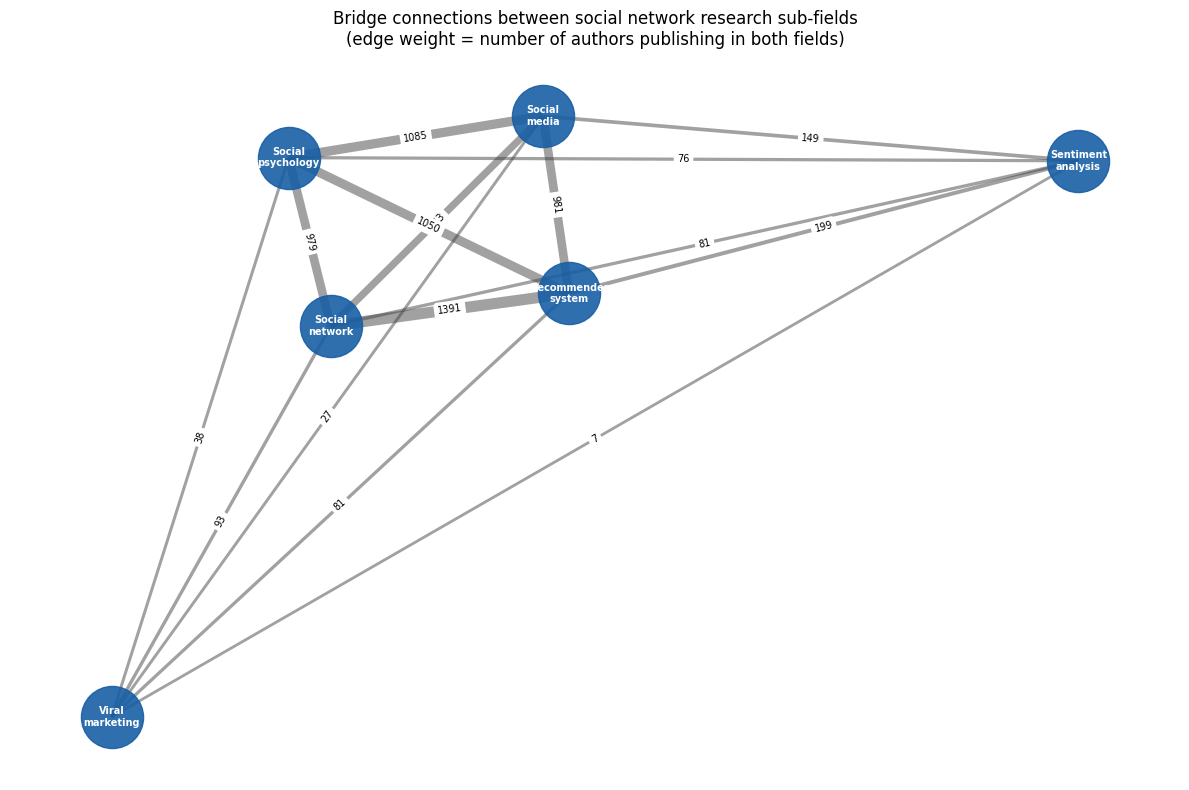

In [ ]:
# Remove Social Semantic Web and Social network analysis - isolated node adds no information
SOCIAL_FIELDS_GRAPH = [f for f in SOCIAL_FIELDS 
                        if f not in ["Social Semantic Web", "Social network analysis"]]

# Rebuild with better layout parameters
G2 = nx.Graph()
for f in SOCIAL_FIELDS_GRAPH:
    G2.add_node(f)
for f1, f2, count in pair_counts:
    if f1 in SOCIAL_FIELDS_GRAPH and f2 in SOCIAL_FIELDS_GRAPH:
        G2.add_edge(f1, f2, weight=count)

weights2 = [G2[u][v]["weight"] for u, v in G2.edges()]
max_w2 = max(weights2)
norm_weights2 = [2 + 6 * (w / max_w2) for w in weights2]

pos2 = nx.spring_layout(G2, seed=99, k=3.5)  # k mais alto = mais espaço
short_labels2 = {f: f.replace(" ", "\n") for f in SOCIAL_FIELDS_GRAPH}

plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G2, pos2, node_size=2000, node_color="#185FA5", alpha=0.9)
nx.draw_networkx_labels(G2, pos2, labels=short_labels2, font_size=7,
                        font_color="white", font_weight="bold")
nx.draw_networkx_edges(G2, pos2, width=norm_weights2, alpha=0.5, edge_color="#444444")
edge_labels2 = {(u, v): d["weight"] for u, v, d in G2.edges(data=True)}
nx.draw_networkx_edge_labels(G2, pos2, edge_labels=edge_labels2, font_size=7)
plt.title("Bridge connections between social network research sub-fields\n"
          "(edge weight = number of authors publishing in both fields)")
plt.axis("off")
plt.tight_layout()
plt.show()

Recommender Systems is the most connected field in the ecosystem, with 1,391 bridge authors shared with Social Network, 1,085 with Social Media, and 979 with Social Psychology. It sits at the centre of the research community, acting as the primary hub where methods from different fields converge.

Sentiment Analysis connects most strongly to Recommender Systems (199 authors) and Social Media (149 authors), confirming its role as a technology that feeds directly into recommendation and social media applications. Viral Marketing sits on the periphery with weaker connections to all fields, consistent with it being more commercially-driven and less embedded in the core academic research network.

### 14.8 Shortest Paths to Influential Papers

Shortest paths measures how many citation hops separate each paper from the most influential papers in the social network research field. Papers close to these landmarks sit at the core of the field, while distant ones are on the periphery. We use the three most cited social papers as landmarks.

In [43]:
# ============================================================
# Shortest Paths within the social network research subgraph
# How far is each social paper from the most influential ones?
# ============================================================

# Landmarks: 3 most-cited papers in the social citation subgraph
soc_landmarks = (
    soc_cites_g.inDegrees
    .join(soc_cites_g.vertices.select("id"), on="id", how="inner")
    .orderBy(F.desc("inDegree"))
    .limit(3)
    .select("id")
    .rdd.flatMap(lambda x: x)
    .collect()
)
soc_landmark_names = [
    vertices.filter(F.col("id") == lid).first()["name"][:45]
    for lid in soc_landmarks
]
print("Landmark papers (social subgraph):")
for n in soc_landmark_names:
    print(f"  - {n}")

# (!) BIG-DATA NOTE: shortestPaths runs BFS from every node to the landmarks.
# Bounded by the small number of landmarks, so it scales acceptably.
soc_sp = soc_cites_g.shortestPaths(landmarks=soc_landmarks)

main_lm = soc_landmarks[0]
soc_distance_dist = (
    soc_sp.select("id", F.col("distances").getItem(main_lm).alias("dist"))
    .filter(F.col("dist").isNotNull())
    .groupBy("dist")
    .count()
    .orderBy("dist")
)
print(f"\nDistance distribution to '{soc_landmark_names[0]}':")
soc_distance_dist.show()

Landmark papers (social subgraph):
  - Factorization Machines with libFM
  - What makes a helpful online review? a study o
  - Performance of recommender algorithms on top-

Distance distribution to 'Factorization Machines with libFM':
+----+-----+
|dist|count|
+----+-----+
|   0|    1|
|   1|   62|
|   2|   60|
|   3|   19|
|   4|    1|
+----+-----+



The three most cited papers in the social subgraph are used as landmarks. The distance distribution to the top landmark (Factorization Machines with libFM) shows that most papers reach it within 2 hops: 62 papers cite it directly (distance 1) and 60 more are 2 hops away. Only 1 paper requires 4 hops, confirming that the core of the social network research community is tightly connected around its most influential works.

### 14.9 Venue Diversity - Interdisciplinary vs. Specialised Conferences

Which conferences and journals publish across the most social-network research
sub-fields? A venue covering many fields acts as a mixing point for ideas.
A specialised venue keeps communities separate.

In [44]:
venue_diversity = (
    social_g.edges
    .filter(F.col("rel_type") == "published_in")
    .join(
        social_g.vertices
        .filter(F.col("node_type") == "paper")
        .select(F.col("id").alias("src"), "primary_field"),
        "src", "left"
    )
    .filter(F.col("primary_field").isNotNull())
    .groupBy("dst")
    .agg(
        F.countDistinct("primary_field").alias("num_fields"),
        F.count("*").alias("total_papers"),
        F.collect_set("primary_field").alias("fields_covered"),
    )
    .filter(F.col("total_papers") >= 10)
    .join(
        vertices.filter(F.col("node_type") == "venue")
               .select(F.col("id").alias("dst"), "name"),
        "dst", "left"
    )
    .orderBy(F.desc("num_fields"), F.desc("total_papers"))
    .cache()
)

print("=== Most interdisciplinary venues ===")
venue_diversity.select("name", "num_fields", "total_papers", "fields_covered")     .show(10, truncate=55)

print("\n=== Most specialised venues (only 1 sub-field) ===")
venue_diversity.filter(F.col("num_fields") == 1)     .orderBy(F.desc("total_papers"))     .select("name", "num_fields", "total_papers", "fields_covered")     .show(10, truncate=55)

=== Most interdisciplinary venues ===
+-------------------------------------------------------+----------+------------+-------------------------------------------------------+
|                                                   name|num_fields|total_papers|                                         fields_covered|
+-------------------------------------------------------+----------+------------+-------------------------------------------------------+
|                                   Information Sciences|         7|         140|[Viral marketing, Social media, Recommender system, ...|
|                       Expert Systems With Applications|         6|         265|[Viral marketing, Social media, Recommender system, ...|
|         National Conference on Artificial Intelligence|         6|         200|[Viral marketing, Social media, Recommender system, ...|
|                                Knowledge Based Systems|         6|         163|[Viral marketing, Social media, Recommender system, .

Information Sciences is the most interdisciplinary venue, covering 7 of the 8 social research fields with 140 papers. Expert Systems With Applications and the AAAI National Conference follow with 6 fields each. These venues act as mixing points where ideas from recommender systems, sentiment analysis, and social media research converge.

The most specialised venues are exclusively in social psychology, with Human Factors (223 papers) and Intelligent Virtual Agents (211 papers) publishing only within that sub-field. This confirms that social psychology remains relatively isolated from the more computational sub-fields like recommender systems and sentiment analysis.

In [45]:
# Top venues for Sentiment Analysis papers
sa_venues = (
    social_g.edges
    .filter(F.col("rel_type") == "published_in")
    .join(
        social_vertices
        .filter(F.col("node_type") == "paper")
        .filter(F.col("primary_field") == "Sentiment analysis")
        .select(F.col("id").alias("src")),
        "src", "inner"
    )
    .join(
        social_vertices
        .filter(F.col("node_type") == "venue")
        .select(F.col("id").alias("dst"), "name"),
        "dst", "inner"
    )
    .groupBy("name")
    .count()
    .orderBy(F.desc("count"))
)
print("Top venues publishing Sentiment Analysis research:")
sa_venues.show(10, truncate=50)

Top venues publishing Sentiment Analysis research:
+--------------------------------------------------+-----+
|                                              name|count|
+--------------------------------------------------+-----+
|  Empirical Methods in Natural Language Processing|   21|
|Meeting of the Association for Computational Li...|   20|
|                   arXiv: Computation and Language|   19|
|International Conference on Computational Lingu...|   16|
|                                        TASS@SEPLN|    9|
|North American Chapter of the Association for C...|    8|
|    National Conference on Artificial Intelligence|    8|
|                 Language Resources and Evaluation|    7|
|          Journal of Intelligent and Fuzzy Systems|    7|
|                           Knowledge Based Systems|    6|
+--------------------------------------------------+-----+
only showing top 10 rows



Sentiment Analysis research is concentrated in Natural Language Processing venues: EMNLP, ACL, and arXiv lead the publication count, confirming that Sentiment Analysis is fundamentally an NLP problem. For a client operating in the social media space, this means the most relevant research talent and partnerships are found in the NLP academic community rather than in social network or marketing conferences.

### 14.10 Six Degrees of Separation - Sentiment Analysis -> Viral Marketing

A classic social-network concept: any two people are connected by at most six
acquaintances. We test the academic equivalent: how many citation hops separate
a **Sentiment Analysis** paper from a **Viral Marketing** paper?

These two sub-fields study very different aspects of online behaviour, so if
they are close in the citation graph it means ideas flow between them.

In [ ]:
# Most-cited Sentiment Analysis paper as landmark
sa_landmark_row = (
    soc_cites_g.inDegrees
    .join(
        social_vertices
        .filter(F.col("primary_field") == "Sentiment analysis")
        .select("id"),
        "id", "inner"
    )
    .orderBy(F.desc("inDegree"))
    .first()
)
sa_id   = sa_landmark_row["id"]
sa_name = vertices.filter(F.col("id") == sa_id).first()["name"]
print(f"Landmark (Sentiment Analysis): {sa_name}")

# (!) BIG-DATA NOTE: .collect() here is safe because vm_ids was limited to
# 30 rows before collection. The list is used to build a BFS fromExpr string.
# Sample of Viral Marketing papers as starting points
vm_ids = (
    social_vertices
    .filter(F.col("primary_field") == "Viral marketing")
    .filter(F.col("node_type") == "paper")
    .select("id")
    .limit(30)
)
vm_id_list = [r["id"] for r in vm_ids.collect()]
vm_expr = " OR ".join([f"id = '{i}'" for i in vm_id_list])

print(f"Starting from {len(vm_id_list)} Viral Marketing papers...")

# (!) BIG-DATA NOTE: BFS bounded by maxPathLength for tractability
paths = soc_cites_g.bfs(
    fromExpr=vm_expr,
    toExpr=f"id = '{sa_id}'",
    maxPathLength=6,
)
path_count = paths.count()
print(f"\nPaths found within 6 hops: {path_count:,}")

if path_count > 0:
    ncols = len(paths.columns)
    hops  = (ncols - 1) // 2
    print(f"Shortest path found: {hops} hop(s)")
    print("\nSample paths:")
    paths.select(
        F.col("from.name").alias("viral_marketing_paper"),
        F.col("to.name").alias("sentiment_landmark"),
    ).show(5, truncate=55)
else:
    print("No direct citation path within 6 hops.")
    print("These sub-fields cite largely different foundational work.")

Landmark (Sentiment Analysis): Adaptive Recursive Neural Network for Target-dependent Twitter Sentiment Classification
Starting from 30 Viral Marketing papers...

Paths found within 6 hops: 0
No direct citation path within 6 hops.
These sub-fields cite largely different foundational work.


No citation path exists between the Viral Marketing papers and the Sentiment Analysis landmark within 6 hops. Despite both fields studying online human behaviour, they cite largely different foundational literature and do not reference each other's core works.

This is itself an interesting finding: two fields that are conceptually related are structurally disconnected in the citation network, suggesting they developed independently and have not yet converged in the literature.

### 14.11 Motif Finding - Co-citation Patterns in Social Network Research

Same motif as Section 11 (co-citation), now restricted to the social subgraph.
We also add a second motif: **author-paper-venue triangles**, finding authors
who published two papers at the same venue - revealing venue loyalty patterns.

In [47]:
# Motif 1: co-citation within social papers
# Papers a and b both cited by paper c - within the social field
print("=== Motif 1: Most co-cited social network paper pairs ===")
soc_co_cite = (
    soc_cites_g.find("(c)-[e1]->(a); (c)-[e2]->(b)")
    .filter("a.id < b.id")
    .filter("a.node_type = 'paper'")
    .filter("b.node_type = 'paper'")
)
(
    soc_co_cite
    .groupBy(F.col("a.name").alias("paper_a"),
             F.col("b.name").alias("paper_b"))
    .agg(F.countDistinct("c").alias("co_citations"))
    .orderBy(F.desc("co_citations"))
    .show(10, truncate=45)
)

=== Motif 1: Most co-cited social network paper pairs ===


+---------------------------------------------+---------------------------------------------+------------+
|                                      paper_a|                                      paper_b|co_citations|
+---------------------------------------------+---------------------------------------------+------------+
|Ups and Downs: Modeling the Visual Evoluti...|Interpretable Convolutional Neural Network...|           5|
|            Context-Aware Recommender Systems|InCarMusic: Context-Aware Music Recommenda...|           5|
|            Factorization Machines with libFM|DKN: Deep Knowledge-Aware Network for News...|           5|
|Comparison of collaborative filtering algo...|A Comprehensive Survey of Neighborhood-Bas...|           4|
|            Context-Aware Recommender Systems|A Comprehensive Survey of Neighborhood-Bas...|           4|
|A Comprehensive Survey of Neighborhood-Bas...|Performance of recommender algorithms on t...|           4|
|Weak‐Tie Support Network Preference 

The most co-cited pairs are recommender systems papers, with a maximum of 5 co-citations. The numbers are much lower than in the full graph (where Deep Learning pairs reached thousands of co-citations), reflecting the smaller and more fragmented nature of the social subgraph.

The pairs that emerge make intuitive sense: context-aware recommender systems papers cluster together, as do neighbourhood-based recommendation surveys. The low co-citation counts suggest this subgraph does not have the same dominant foundational works as the full CS graph.

In [48]:
# Motif 2: author published 2 papers at the same venue
# Pattern: author wrote paper1, author wrote paper2,
#          paper1 published_in venue, paper2 published_in venue
# (!) BIG-DATA NOTE: 4-node motif - expensive; run on social subgraph only
print("=== Motif 2: Authors with venue loyalty (2 papers, same venue) ===")
venue_loyal = (
    social_g.find(
        "(a)-[e1]->(p1); (a)-[e2]->(p2); (p1)-[e3]->(v); (p2)-[e4]->(v)"
    )
    .filter("e1.rel_type = 'wrote'")
    .filter("e2.rel_type = 'wrote'")
    .filter("e3.rel_type = 'published_in'")
    .filter("e4.rel_type = 'published_in'")
    .filter("p1.id < p2.id")   # avoid mirror pairs
)
(
    venue_loyal
    .groupBy(
        F.col("a.name").alias("author"),
        F.col("v.name").alias("venue"),
    )
    .agg(F.countDistinct("p1").alias("papers_at_venue"))
    .orderBy(F.desc("papers_at_venue"))
    .show(10, truncate=50)
)

=== Motif 2: Authors with venue loyalty (2 papers, same venue) ===


+--------------------+---------------------------------+---------------+
|              author|                            venue|papers_at_venue|
+--------------------+---------------------------------+---------------+
|     Francesco Ricci|Conference on Recommender Systems|             21|
|       Pasquale Lops|Conference on Recommender Systems|             19|
|   Giovanni Semeraro|Conference on Recommender Systems|             17|
|     Marco de Gemmis|Conference on Recommender Systems|             16|
|         Robin Burke|Conference on Recommender Systems|             15|
|     Paolo Cremonesi|Conference on Recommender Systems|             15|
|Martijn C. Willemsen|Conference on Recommender Systems|             15|
|   Joseph A. Konstan|Conference on Recommender Systems|             15|
|           Alan Said|Conference on Recommender Systems|             13|
|       Martha Larson|Conference on Recommender Systems|             13|
+--------------------+-----------------------------

The venue loyalty motif reveals that the top authors in this subgraph are heavily concentrated in the Conference on Recommender Systems (RecSys), with Francesco Ricci publishing 21 papers there. The top 10 are all RecSys regulars, confirming that recommender systems has a tight, dedicated community that returns consistently to the same venue.

This contrasts with the bridge authors analysis, where the most interdisciplinary researchers spread across many fields and venues. Here we see the other end of the spectrum: specialists who publish prolifically within a single community.

### 14.12 Summary - Social Network Research Graph

The social network research subgraph contains 174,876 papers, 74,026 authors, and 3,586 venues, connected by 549,321 edges.

The most influential paper by PageRank is "What Makes a Helpful Online Review? A Study of Customer Reviews on Amazon.Com" (2010), a recommender systems paper focused on user-generated content. The top bridge author is Philip S. Yu, publishing across 5 distinct sub-fields with 55 papers. The most interdisciplinary venue is Information Sciences, covering 7 of the 8 social research fields.

The subgraph is far more fragmented than the global CS graph: only 16.1% of papers belong to the giant component, compared to 98.4% globally. Label propagation detected 17,500 communities, reflecting the diverse and interdisciplinary nature of the field.

**Link to the YouTube sentiment pipeline.** Sentiment analysis is the 4th largest field in this subgraph and bridges social media, NLP, and recommender systems in the citation network. Bridge authors carry methods across these sub-fields, yet Viral Marketing and Sentiment Analysis do not share a direct citation path within 6 hops - two fields that study online behaviour but developed largely independently.